# 8.4.2 活跃集与可行性核验

## 学习目标与先修知识

枚举小型二次规划的活跃集（active set），区分可行最优、不可行与数值失败。

先修：8.4.1的四类KKT条件和线性方程组（system of linear equations）。 [本篇学习次序](../README.md)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

总预算变化时，哪些边界先起作用？如果最低需求已超过预算，增加求解次数能补救吗？

In [1]:
import math
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "DejaVu Sans"]
BLUE, PINK, GREEN, GRAY = "#327cac", "#c35178", "#338b7c", "#68768a"

## 初步实验

In [2]:
lower=np.array([.5,.5]);upper=np.array([3.,3.])
for B in [.8,2.,5.]:
    print('预算',B,'最小需求和',sum(lower),'可行',bool(np.all(lower<=upper) and sum(lower)<=B))

预算 0.8 最小需求和 1.0 可行 False
预算 2.0 最小需求和 1.0 可行 True
预算 5.0 最小需求和 1.0 可行 True


## 模型假设

仅求二维严格凸二次目标，H对称正定（positive definite），约束为ℓ≤x≤u以及x₁+x₂≤B，参数（parameter）已无量纲（dimensionless）化。所有边界包含等号，可行集合紧；非空时最小点存在且唯一。枚举适用于教学中的小维度，不推广为高维高效算法。

## 数学解释与推导


本题可行性有直接判据：每个下界不超过上界，并且 $\ell_1+\ell_2\le B$。
必要性来自所有可行点都逐坐标不小于下界；充分性由直接取 $x=\ell$ 得到。
因而违反此判据时可以报告 `infeasible`，而求解器退出或一个候选违规都不构成这个证明。

将约束统一写成 $Ax\le c$。猜测活跃行集合I，求解
$$\begin{pmatrix}H&A_I^T\\A_I&0\end{pmatrix}\begin{pmatrix}x\\\lambda_I\end{pmatrix}=\begin{pmatrix}b\\c_I\end{pmatrix}.$$
非活跃乘子设0，然后检查所有约束、乘子非负及驻点（stationary point）、互补条件。
先试无活跃约束，再试单边和两条线性独立边。二维中任何法向锥元素可由至多两条独立生成法向的非负组合表达；退化交点可能有更多紧约束，但不必全塞进奇异方程组。
例如上下界相等时可行集合只有点或线，跳过奇异组合仍须保留其他有效候选。

独立核验可换一种几何方式：逐条可行边参数化为 $x=a+td$。
边上目标是一元二次函数，若 $d\ne0$，无约束最小参数为
$$t^*=\frac{d^T(b-Ha)}{d^THd}.$$
把t截在该边的允许区间，再与无约束内部点比较；这与求乘子的活跃集方程不同。
仅对原坐标逐坐标截断无约束点一般不够，交叉项和总预算都会耦合坐标。

硬约束要求每个被接受的解都满足限制；软约束把违反程度加入代价，允许付代价越界。
例如把 $\min (x-2)^2/2$ 的硬约束 $x\le1$ 改成平方罚项，得到
$$\min_x\frac{(x-2)^2}{2}+\frac\rho2\max(x-1,0)^2.$$
对任意有限 $\rho>0$，在 $x>1$ 求导得最小点 $x=(2+\rho)/(1+\rho)>1$。
加大这个惩罚使违反量变小，却不能把有限惩罚解称为满足原硬约束；两种问题须分开报告。


## 核心实现

按上述推导逐步计算；保留明确的更新预算与返回标签。

In [3]:
def quadratic(matrix, linear, point):
    """f(x)=xᵀHx/2-bᵀx; inputs use the same dimensionless coordinates."""
    gradient = [sum(a*x for a, x in zip(row, point))-b
                for row, b in zip(matrix, linear)]
    value = sum(x*(g-b) for x, g, b in zip(point, gradient, linear))/2
    return value, gradient, [list(row) for row in matrix]


def solve_linear(matrix, right):
    """Partial-pivot elimination for the tiny classroom systems."""
    rows = [list(map(float, row))+[float(value)] for row, value in zip(matrix, right)]
    size = len(rows)
    for column in range(size):
        pivot = max(range(column, size), key=lambda i: abs(rows[i][column]))
        if abs(rows[pivot][column]) < 1e-12:
            return None
        rows[column], rows[pivot] = rows[pivot], rows[column]
        scale = rows[column][column]
        rows[column] = [value/scale for value in rows[column]]
        for i in range(size):
            if i != column:
                factor = rows[i][column]
                rows[i] = [a-factor*b for a, b in zip(rows[i], rows[column])]
    return [row[-1] for row in rows]


def box_budget_qp(matrix, linear, lower, upper, budget):
    """Two variables, positive definite objective; enumerate independent active normals."""
    if any(a>b for a, b in zip(lower, upper)) or sum(lower)>budget:
        return None, None, 'infeasible'
    constraints = [[-1.,0.],[0.,-1.],[1.,0.],[0.,1.],[1.,1.]]
    bounds = [-lower[0],-lower[1],upper[0],upper[1],budget]
    candidates = []
    for size in range(3):
        for active in combinations(range(5), size):
            rows = [constraints[i] for i in active]
            block = [list(matrix[i])+[row[i] for row in rows] for i in range(2)]
            block += [list(row)+[0.]*size for row in rows]
            solution = solve_linear(block, list(linear)+[bounds[i] for i in active])
            if solution is None:
                continue
            point, multipliers = solution[:2], solution[2:]
            if any(sum(a*x for a, x in zip(row, point))-bound>1e-9 for row, bound in zip(constraints,bounds)):
                continue
            if any(value < -1e-9 for value in multipliers):
                continue
            candidates.append((quadratic(matrix,linear,point)[0], point))
    if not candidates:
        return None, None, 'numerical_failure'
    value, point = min(candidates, key=lambda item:item[0])
    return point, value, 'optimal'


def kkt_residuals(matrix, linear, constraints, bounds, point, multipliers, tolerance):
    _, gradient, _ = quadratic(matrix, linear, point)
    violation = [sum(a*x for a, x in zip(row, point))-c for row, c in zip(constraints, bounds)]
    stationarity = [g+sum(row[j]*v for row, v in zip(constraints, multipliers))
                    for j, g in enumerate(gradient)]
    primal = max([0.]+violation)
    dual = max([0.]+[-value for value in multipliers])
    stationary = max([0.]+[abs(x) for x in stationarity])
    complementary = max([0.]+[abs(v*r) for v, r in zip(multipliers, violation)])
    residuals = [primal, dual, stationary, complementary]
    return residuals, 'verified' if max(residuals)<=tolerance else 'rejected'


def budget_certificate(matrix, linear, lower, upper, budget):
    point, value, status = box_budget_qp(matrix, linear, lower, upper, budget)
    if point is None:
        return None, None, None, status
    constraints = [[-1.,0.],[0.,-1.],[1.,0.],[0.,1.],[1.,1.]]
    bounds = [-lower[0],-lower[1],upper[0],upper[1],budget]
    gradient = quadratic(matrix, linear, point)[1]
    tight = [i for i,(row,c) in enumerate(zip(constraints,bounds))
             if abs(sum(a*x for a,x in zip(row,point))-c)<1e-8]
    for size in range(3):
        for active in combinations(tight,size):
            rows = [constraints[i] for i in active]
            gram = [[sum(a*b for a,b in zip(r,s)) for s in rows] for r in rows]
            right = [-sum(a*g for a,g in zip(row,gradient)) for row in rows]
            weights = solve_linear(gram,right) if size else []
            if weights is None or any(w < -1e-8 for w in weights):
                continue
            multipliers = [0.]*5
            for i,w in zip(active,weights): multipliers[i]=w
            residuals,check = kkt_residuals(matrix,linear,constraints,bounds,point,multipliers,1e-8)
            if check=='verified':
                return point,value,residuals,'optimal'
    return point,value,None,'numerical_failure'

## 对照实验

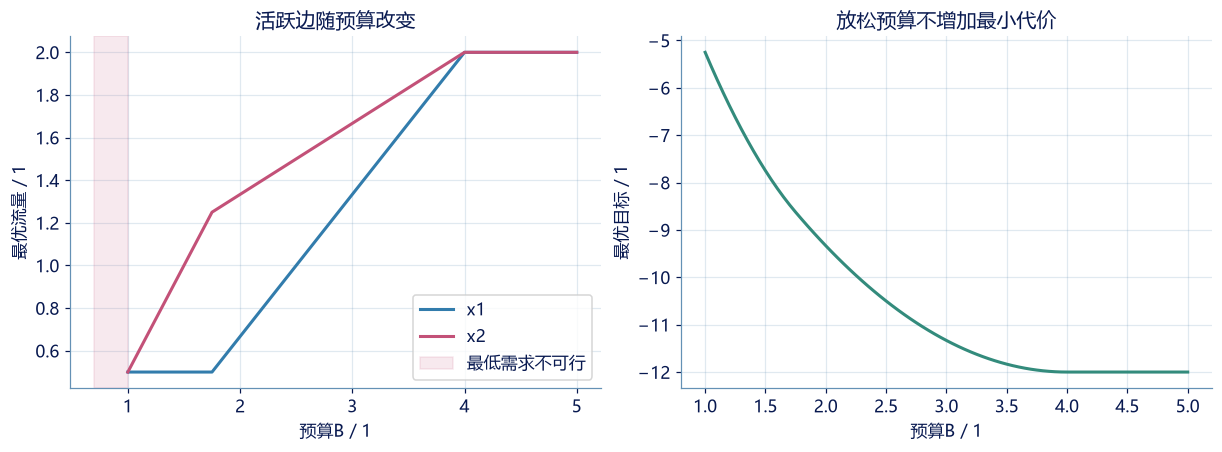

预算 0.8 (None, None, None, 'infeasible')
预算 2.0 ([0.6666666666666667, 1.3333333333333335], -9.333333333333334, [0.0, 0.0, 4.440892098500626e-16, 0.0], 'optimal')
预算 5.0 ([2.0, 2.0], -12.0, [0.0, 0.0, 0.0, 0.0], 'optimal')


In [4]:
H=np.diag([2.,4.]);b=np.array([4.,8.]);budgets=np.linspace(.7,5,87);points=[];costs=[]
for B in budgets:
    point,value,residual,status=budget_certificate(H.tolist(),b.tolist(),lower.tolist(),upper.tolist(),float(B))
    points.append(point if point is not None else [np.nan,np.nan]);costs.append(value if value is not None else np.nan)
points=np.array(points)
fig,axes=plt.subplots(1,2,figsize=(11,4))
for j,color in enumerate([BLUE,PINK]):axes[0].plot(budgets,points[:,j],color=color,label=f'x{j+1}')
axes[0].axvspan(.7,1.,color=PINK,alpha=.12,label='最低需求不可行');axes[0].set(xlabel='预算B / 1',ylabel='最优流量 / 1',title='活跃边随预算改变');axes[0].legend()
axes[1].plot(budgets,costs,color=GREEN);axes[1].set(xlabel='预算B / 1',ylabel='最优目标 / 1',title='放松预算不增加最小代价');plt.show()
for B in [.8,2.,5.]:print('预算',B,budget_certificate(H.tolist(),b.tolist(),lower.tolist(),upper.tolist(),B))

### 独立核验与边界

In [5]:
# 独立一维边界最小化：B=2，边界x2=2−x1。
a=np.array([0.,2.]);d=np.array([1.,-1.]);t=float(d@(b-H@a)/(d@H@d));expected=a+np.clip(t,.5,1.5)*d
point,value,residual,status=budget_certificate(H.tolist(),b.tolist(),lower.tolist(),upper.tolist(),2.)
np.testing.assert_allclose(point,expected);assert max(residual)<1e-8
assert box_budget_qp(H,b,[1.,1.],[1.,1.],2.)[-1]=='optimal'
assert box_budget_qp(H,b,[1.,1.],[3.,3.],1.)[-1]=='infeasible'
for rho in [1.,10.,100.]:assert (2+rho)/(1+rho)>1  # 有限平方惩罚仍允许越界
valid=np.isfinite(costs);assert np.all(np.diff(np.array(costs)[valid])<=1e-10)
print('几何解、单点可行集、不可行下界和预算单调性已核验。')

几何解、单点可行集、不可行下界和预算单调性已核验。


## 结果解释

预算不足由约束本身决定；在可行区间中，活跃集改变会产生分段轨迹（trajectory）。紧约束不必都有正乘子。若只是计算失败，要报告numerical_failure并保留问题，不能擅自删约束或宣称不可行。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：求解带上下界和预算的二次目标

两个可调流量（flow）已除以共同参考流量，求满足上下界及总预算的唯一最优配置。

**函数与代码模板**

```python
def solve(
    matrix: list[list[float]],
    linear: list[float],
    lower: list[float],
    upper: list[float],
    budget: float,
) -> tuple[list[float] | None, float | None, str]:
    # 按题目说明计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `matrix` | `list[list[float]]` | 对称目标矩阵（matrix） H，目标为 xᵀHx/2−bᵀx。 | 无量纲 |
| `linear` | `list[float]` | 线性项 b，符号按目标中的减号。 | 无量纲 |
| `lower` | `list[float]` | 两坐标的下界ℓ。 | 无量纲 |
| `upper` | `list[float]` | 两坐标的上界u。 | 无量纲 |
| `budget` | `float` | 总量上限B，要求x₁+x₂≤B。 | 无量纲 |

**返回值**

按以下顺序返回元组：(point, objective, status)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `point` | <code>list[float] &#124; None</code> | 最优坐标，未取得解时None。 | 无量纲 |
| `objective` | <code>float &#124; None</code> | 该点目标值，无解时None。 | 无量纲 |
| `status` | `str` | optimal、infeasible或numerical_failure。 | 不适用 |

**计算规则**

若任一下界大于上界，或下界和大于budget，返回None,None,infeasible。否则求严格凸二次目标的唯一最小点；允许枚举边、顶点或活跃集（active set）。numerical_failure只表示计算失败，不能替代不可行判定。

**约束与边界**

- 二维H正定（positive definite），特征值（eigenvalue）在[0.1,20]；0≤下界、上界≤5；0≤budget≤10；线性项绝对值≤20；不得只把无约束解逐坐标截断。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| matrix | 对称目标矩阵（matrix） H，目标为 xᵀHx/2−bᵀx。 | [[2.0, 0.0], [0.0, 4.0]] | 无量纲 |
| linear | 线性项 b，符号按目标中的减号。 | [4.0, 8.0] | 无量纲 |
| lower | 两坐标的下界ℓ。 | [0.0, 0.0] | 无量纲 |
| upper | 两坐标的上界u。 | [3.0, 3.0] | 无量纲 |
| budget | 总量上限B，要求x₁+x₂≤B。 | 2 | 无量纲 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
matrix = [[2.0, 0.0], [0.0, 4.0]]
linear = [4.0, 8.0]
lower = [0.0, 0.0]
upper = [3.0, 3.0]
budget = 2.0

result = solve(matrix, linear, lower, upper, budget)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| point | 最优坐标，未取得解时None。 | [0.6666666666666667, 1.3333333333333335] | 无量纲 |
| objective | 该点目标值，无解时None。 | ≈ -9.333333 | 无量纲 |
| status | optimal、infeasible或numerical_failure。 | optimal | 不适用 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.6666666666666667, 1.3333333333333335],
                   -9.333333333333334,
                   'optimal')
```

**样例解释**

预算活跃，解为[2/3,4/3]，目标−28/3；截断[2,2]不能满足总预算。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：求解带上下界和预算的二次目标](http://127.0.0.1:8000/chapters/08-04-%E7%BA%A6%E6%9D%9F%E4%B8%8E%E6%9C%80%E4%BC%98%E6%80%A7%E6%9D%A1%E4%BB%B6/practice/?question=p08-budget-qp)

### 第 2 题 · 单项选择题：一次候选失败能证明什么

某求解器返回候选x，发现违反一条约束。此时最可靠的报告是？

- **A.** 问题不可行。
- **B.** 当前候选不可行，问题是否可行仍需证据。
- **C.** 增加迭代必能修好。
- **D.** 删除该约束但继续报告原问题结果。

[作答：一次候选失败能证明什么](http://127.0.0.1:8000/chapters/08-04-%E7%BA%A6%E6%9D%9F%E4%B8%8E%E6%9C%80%E4%BC%98%E6%80%A7%E6%9D%A1%E4%BB%B6/practice/?question=p08-feasible-or-failed)

### 第 3 题 · 多项选择题：截断为什么不够

H=[[2,1],[1,2]]，两个坐标又受总预算约束。为什么不能默认逐坐标截断无约束解就是约束最优？

- **A.** 交叉项使一个坐标影响另一个的代价。
- **B.** 总预算把两个坐标耦合。
- **C.** 任意正定（positive definite）H都能用普通欧氏截断得到约束解。
- **D.** 应在可行集合上比较完整目标或核验KKT。

[作答：截断为什么不够](http://127.0.0.1:8000/chapters/08-04-%E7%BA%A6%E6%9D%9F%E4%B8%8E%E6%9C%80%E4%BC%98%E6%80%A7%E6%9D%A1%E4%BB%B6/practice/?question=p08-clip-coupling)

### 第 4 题 · 多项选择题：放宽约束和多跑几步

原问题要求x₁+x₂≤B，改成超额惩罚ρmax(0,x₁+x₂−B)²。哪些判断正确？

- **A.** 有限ρ一般允许一定违规。
- **B.** 这与原硬约束完全等价。
- **C.** 增加迭代预算只改变求解过程，放宽B则改变可行集合。
- **D.** 比较方案时应另报告实际违规量。

[作答：放宽约束和多跑几步](http://127.0.0.1:8000/chapters/08-04-%E7%BA%A6%E6%9D%9F%E4%B8%8E%E6%9C%80%E4%BC%98%E6%80%A7%E6%9D%A1%E4%BB%B6/practice/?question=p08-soft-hard)

### 延伸阅读

[Boyd 与 Vandenberghe：《Convex Optimization》](https://web.stanford.edu/~boyd/cvxbook/)，第4章的二次规划、第5章的最优性条件。

[概念探索与交互](http://127.0.0.1:8000/chapters/08-04-约束与最优性条件/explore/) · [本篇目录](../README.md)